# Homework 7

## Your Name Here (or your names here if you are pair programming)

Student Name: Lily Nguyen

Student UT EID: lmn934

---

Partner Name: John "Jack" Mayberry

Partner UT EID: jmm23398

---

Date Created: Wednesday, July 16th, 2025

Date Last Modified:

---

Total Points 20. 



## Supprt Vector Machine 

In [1]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [2]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task - 1 Implement SVM using libraries (4 points)
We want to use **Suppert Vector Machine** to perdict if the patients will have heart problems or not. The column "Target" in our datasets includes data about heart diseases. If the patient had heart disease we have a 1 and if not a zero. 

Prepare your data set for predicting heart disease ("Target" column) out of 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 


Split your data into 80% traning data and 20% test data, and implement Support Vector Machine using Scikit-Learn. 





In [3]:
# data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = heart_df[['Age', 'Sex', 'Chol']]
y = heart_df['Target'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(242, 3) (61, 3) (242,) (61,)


In [4]:
# Import the necessary packages and create an SVM model
from sklearn import svm
from sklearn.metrics import accuracy_score

# establish and fit the model
model = svm.SVC()
model.fit(X_train, y_train)

# run the model on the train/test data and determine the accuracy
y_pred = model.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.6065573770491803


# Task 2 - (4 points)

Cacluate the accuracy, Precision, Recall and F1 score of your **SVM** implementaion from Task 1. 
Print the results. 

You may use library methods for this task if you choose to.


In [5]:
# Calculate the accuracy, precision, recall, and F1

print("Accuracy Score:", accuracy_score(y_test, y_pred))

# print the classification report using the library method
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

Accuracy Score: 0.6065573770491803
              precision    recall  f1-score   support

           0       0.57      0.69      0.62        29
           1       0.65      0.53      0.59        32

    accuracy                           0.61        61
   macro avg       0.61      0.61      0.61        61
weighted avg       0.61      0.61      0.60        61



# Task 3 - Implement SVM without using libraries  - (4 points)

Implement SVM from scratch using Hinge Loss function and Gradient Descent. 
Try to produce the same result as you get from the libraries. 


* Do as many iterations as needed 
* Do maximum **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher. 
* Visualize your costs. 
* No need to add an y-intercept in this task. 
* You can use libraries to report accuracy, Precision, Recall and F1. 



In [6]:
def compute_cost(X, y, W, regularization_factor):
    '''
    Calculate the hinge loss
    '''
    n = X.shape[0]
    distances = 1 - y * (np.dot(X, W))
    
    distances[distances < 0] = 0 
    
    hinge_loss = regularization_factor * (np.sum(distances) / n)
    return (1 / 2 * np.dot(W, W) + hinge_loss)

def calculate_gradient(X, y, W, regularization_factor):
    '''
    Calculate the gradient descent
    '''
    if type(y) == np.float64:
        y = np.array([y])
        X = np.array([X])
        
    distance = 1 - (y * np.dot(X, W))
    
    dw = np.zeros(len(W))
    
    for ind, d in enumerate(distance):
        
        if (d < 0):
            di = W
        else:
            di = W - (regularization_factor * y[ind] * X[ind])
            
            
        dw += di
    
    dw = dw/len(y)
    
    return dw

In [7]:
weights = np.zeros(3)

num_iterations = 100
learning_rate = 0.1

regularization = 0.01

cost_list = []

for i in range(0, num_iterations):
    
    cost = compute_cost(X_train, y_train, weights, regularization)
    
    print("Epoch", i, "Cost is:", cost, "weights", weights)
    
    cost_list.append(cost)
    
    grad = calculate_gradient(X_train, y_train, weights, regularization)
    
    weights = weights - learning_rate * grad

Epoch 0 Cost is: 0.01 weights [0. 0. 0.]


KeyError: 5

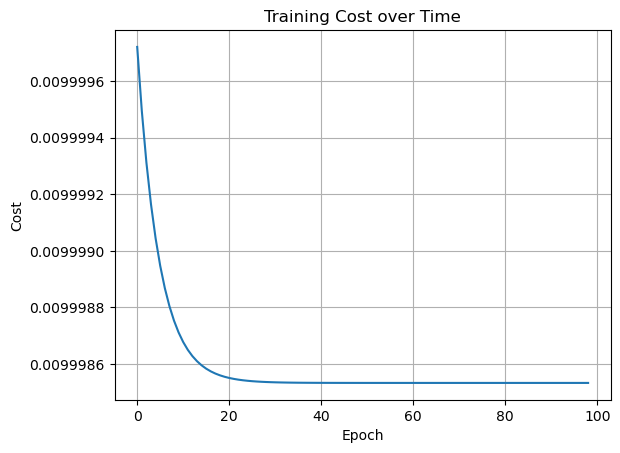

In [ ]:
plt.plot(cost_list[1:])
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Cost over Time")
plt.grid(True)
plt.show()

In [ ]:
def predict_svm(weights, X):
    scores = X.dot(weights)
    return np.where(scores >= 0, 1, 0)

print("Accuracy Score:", accuracy_score(y_test, predict_svm(weights, X_test)))

print(classification_report(y_test,predict_svm(weights, X_test)))

unique_preds, counts = np.unique(predict_svm(weights, X_test), return_counts=True)
print(dict(zip(unique_preds, counts)))

Accuracy Score: 0.7868852459016393
              precision    recall  f1-score   support

         0.0       0.87      0.75      0.81        36
         1.0       0.70      0.84      0.76        25

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.78        61
weighted avg       0.80      0.79      0.79        61

{0: 31, 1: 30}


# Task 4 - Compare SVM results with Logistic Regression - (4 points)

Which model performs better here? Compare your results wit the logistic regression. You can use libraries for this task, it is not necessary to implement logistic regression from sratch.


In [ ]:
# Import Logistic Regression and compare its result with the SVM model
from sklearn.linear_model import LogisticRegression

model_logr = LogisticRegression()
model_logr.fit(X_train,y_train)

y_pred_logr = model.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_logr))
print(classification_report(y_test, y_pred_logr))

print("SVM:", accuracy_score(y_test, predict_svm(weights, X_test)))
print(classification_report(y_test,predict_svm(weights, X_test)))

Logistic Regression: 0.7540983606557377
              precision    recall  f1-score   support

         0.0       0.80      0.78      0.79        36
         1.0       0.69      0.72      0.71        25

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61

SVM: 0.7868852459016393
              precision    recall  f1-score   support

         0.0       0.87      0.75      0.81        36
         1.0       0.70      0.84      0.76        25

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.78        61
weighted avg       0.80      0.79      0.79        61



# Task 5 - Apply a kernel function to improve SVM performance (4 points)

Use the Scikit-learn librariy and apply a kernel function to improve the SVM performance. Check if this is possible. 


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
    model_k = SVC(kernel=kernel, probability=True)  
    model_k.fit(X_train, y_train)
    y_pred_k = model_k.predict(X_test)
    
    print(f"\n=== Kernel: {kernel} ===")
    print(classification_report(y_test, y_pred_k, zero_division=0))
    
    acc = model_k.score(X_test, y_test)
    results[kernel] = acc

print("\nAccuracy by kernel:")
for k, acc in results.items():
    print(f"  {k:7s} → {acc:.3f}")


=== Kernel: linear ===
              precision    recall  f1-score   support

         0.0       0.84      0.75      0.79        36
         1.0       0.69      0.80      0.74        25

    accuracy                           0.77        61
   macro avg       0.77      0.78      0.77        61
weighted avg       0.78      0.77      0.77        61


=== Kernel: poly ===
              precision    recall  f1-score   support

         0.0       0.79      0.53      0.63        36
         1.0       0.54      0.80      0.65        25

    accuracy                           0.64        61
   macro avg       0.67      0.66      0.64        61
weighted avg       0.69      0.64      0.64        61


=== Kernel: rbf ===
              precision    recall  f1-score   support

         0.0       0.75      0.83      0.79        36
         1.0       0.71      0.60      0.65        25

    accuracy                           0.74        61
   macro avg       0.73      0.72      0.72        61
weighte